<div class="alert alert-success">
    <h1>Assignment 1: Deep Learning</h1>
    <h3 align='center'>Computational Intelligence (4032-01)</h3>
    <h5 align='center'>Instructor: Dr.Samane Hosseini</h5>
    <h5 align='center'>TA: Arash Azhand</h5>
</div>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Generate Dataset

In [2]:
def load_moons_dataset():
    # TODO: Generate a dataset with make_moons (2000 samples, noise=0.3, random_state=42)

    # HINT:
    # 1. Use make_moons from sklearn.datasets.
    # 2. Convert X, y into PyTorch tensors of type torch.float32.

    X,y=make_moons(n_samples=2000,noise=0.3,random_state=42)
    X=torch.tensor(X,dtype=torch.float32)
    y=torch.tensor(y,dtype=torch.float32)

    return X, y

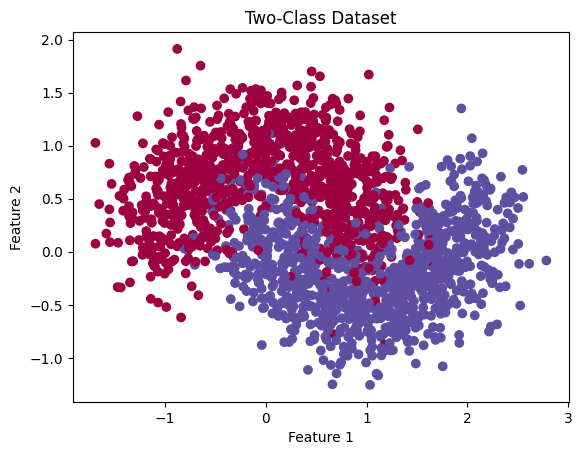

In [3]:
X, y = load_moons_dataset()

plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.Spectral)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Class Dataset")
plt.show()

**Desired Output:**

![image.png](attachment:a9922b19-aaa8-4489-839d-45c47a244dca.png)


# 2. Define Networks

In [4]:
# Define an underfitting model with one hidden layer and too few neurons (3 or 5)
class UnderfitNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(UnderfitNeuralNet, self).__init__()
        # TODO: Define a small neural network with just one hidden layer

        # HINT:
        # 1. First layer: input_dim → 3 neurons
        # 2. Output layer: 3 neurons → 1 neuron

        self.layer1=nn.Linear(input_dim,3)
        self.layer2=nn.Linear(3,1)

    def forward(self, x):
        # TODO: Implement forward pass using ReLU and Sigmoid

        # HINT:
        # 1. Apply ReLU on the first layer.
        # 2. Apply Sigmoid on the final output layer.

        x=self.layer1(x)
        x=torch.relu(x)
        x=self.layer2(x)
        x=torch.sigmoid(x)

        return x

In [5]:
# Define an overfitting model with more than 4 layers and too many neurons in each layer eg:(128, 64, 32)
class OverfitNeuralNet(nn.Module):
    def __init__(self, input_dim):
        super(OverfitNeuralNet, self).__init__()
        # TODO: Define a deep neural network with multiple layers

        # HINT:
        # 1. First hidden layer: input_dim → 128 neurons
        # 2. Second hidden layer: 128 → 64 neurons
        # 3. Third hidden layer: 64 → 32 neurons
        # 3. Fourth hidden layer: 32 → 16 neurons
        # 4. Output layer: 16 → 1 neuron

        self.layer1=nn.Linear(input_dim,128)
        self.layer2=nn.Linear(128,64)
        self.layer3=nn.Linear(64,32)
        self.layer4=nn.Linear(32,16)
        self.layer5=nn.Linear(16,1)

    def forward(self, x):
        # TODO: Implement forward pass using ReLU and Sigmoid

        # HINT:
        # 1. Apply ReLU on all hidden layers.
        # 2. Apply Sigmoid on the final output layer.

        x=self.layer1(x)
        x=torch.relu(x)
        x=self.layer2(x)
        x=torch.relu(x)
        x=self.layer3(x)
        x=torch.relu(x)
        x=self.layer4(x)
        x=torch.relu(x)
        x=self.layer5(x)
        x=torch.sigmoid(x)

        return x

# 3. Move data and models to CUDA (faster training with GPU)

In [6]:
# Ensure CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=86)

# TODO: Move data to CUDA

# HINT:
# 1. Use `.to(device)` to move X_train, X_test, y_train, y_test to the same device.

# Example: X_train = X_train.to(device)

X_train=X_train.to(device)
X_test=X_test.to(device)
y_train=y_train.to(device)
y_test=y_test.to(device)

In [8]:
# TODO: Move the instances of models to the specified device (GPU)
# Hint: You have already defined 'device' earlier.
# Use the `.to(device)` method to move both the underfit and overfit models to the same device as the data.
# Example:
# model = YourModelClass(...).to(device)
simple_model=UnderfitNeuralNet(input_dim=2).to(device)
complicated_model=OverfitNeuralNet(input_dim=2).to(device)


In [9]:
# You can see a summary of yor model along with the number of parameters it has
%pip install torchsummary # !pip install torchsummary --> run this in google colab
from torchsummary import summary
print("Simple Model Summary:")
summary(simple_model, input_size=(2,))
print("Complex Model Summary:")
summary(complicated_model, input_size=(2,))

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Simple Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 3]               9
            Linear-2                    [-1, 1]               4
Total params: 13
Trainable params: 13
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
Complex Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]             384
            Linear-2                   [-1, 64]       

Desired Output:

![image.png](attachment:image.png)

# 4. Train

In [10]:
def train(model, X_train, y_train, num_epochs=1000, batch_size=32, lr=0.01, lambda_reg=0.01, regularization_type=None):
    # TODO: Ensure the model is in training mode
    # This is necessary because some layers (like dropout or batch normalization) behave differently in training vs. evaluation mode.
    model.train()

    # TODO: Define the loss function
    # Hint: We are using Binary Cross Entropy (BCE) since this is a binary classification problem.
    criterion=nn.CrossEntropyLoss()

    # TODO: Define the optimizer
    # Hint: Adam is used here, but you could experiment with other optimizers like SGD or RMSprop.
    optimizer=optim.Adam(model.parameters(),lr=lr)

    dataset = TensorDataset(X_train, y_train)
    # TensorDataset helps us manage input (X) and target (y) pairs in batches.

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    # DataLoader splits the dataset into batches and shuffles them for better training performance.

    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            # TODO: Reset the gradients before backpropagation
            # Hint: PyTorch accumulates gradients by default, so we need to clear them at the start of each batch.
            optimizer.zero_grad()

            # TODO: Perform forward pass
            # Hint: Pass the input through the model to get predictions.
            predictions=model(inputs)

            # TODO: Compute the loss
            # Hint: Make sure the shapes match. if didn't match, you can use outputs.squeeze() which ensures it's the same shape as targets.

            loss=criterion(predictions.squeeze(),targets)

            # TODO: Implement L1 regularization if selected
            if regularization_type == "L1":
                # Hint: L1 regularization adds the absolute value of the weights to the loss.
                # you can access the model parameters with `model.parameters()`
                l1_loss=0
                for param in model.parameters():
                  l1_loss+=torch.sum(torch.abs(param))
                loss+=lambda_reg*l1_loss

            # TODO: Implement L2 regularization if selected
            elif regularization_type == "L2":
                # Hint: L2 regularization adds the squared value of the weights to the loss.
                # you can access the model parameters with `model.parameters()`
                l2_loss=0
                for param in model.parameters():
                  l2_loss+=torch.sum(param**2)
                loss+=lambda_reg*l2_loss

            # TODO: Compute gradients using backpropagation
            # Hint: This step calculates how each weight should be updated.
            loss.backward()

            # TODO: Update model parameters
            # Hint: This applies the calculated gradients to update the model weights.
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        if epoch % 100 == 0:
            print(f"epoch {epoch}, loss: {running_loss}")

    return model

In [11]:
# NOTE: Do not make any changes here
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(torch.linspace(x_min, x_max, 100), torch.linspace(y_min, y_max, 100))
    xx, yy = xx.to(device), yy.to(device)

    with torch.no_grad():
        Z = model(torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)).cpu()
    Z = Z.reshape(xx.shape)

    plt.contourf(xx.cpu().numpy(), yy.cpu().numpy(), Z.numpy(), levels=[0, 0.5, 1], alpha=0.6)
    plt.scatter(X.cpu()[:, 0], X.cpu()[:, 1], c=y.cpu().numpy().flatten(), edgecolor='k')
    plt.title(title)
    plt.show()

# 5. Train Models with Different Configurations and Analyze Their Effects

### Experiment 1: Train the Models Without Regularization  (This is done for you)
- **Train both `UnderfitNeuralNet` and `OverfitNeuralNet` models without any regularization.**  
- **Hint:** Use the existing training function and evaluate their performance. Observe if the overfit model memorizes the training data.  

### Experiment 2: Apply L1 Regularization  
- **Modify the training to include L1 regularization.**  
- **Hint:** Add an L1 penalty term (`lambda_reg * sum(abs(param))`) to the loss function.  
- **Analyze:** Does it improve generalization? Do model weights become sparse?  

### Experiment 3: Apply L2 Regularization  
- **Modify the training function to include L2 regularization.**  
- **Hint:** Add an L2 penalty term (`lambda_reg * sum(param^2)`) to the loss function.  
- **Analyze:** Does it help reduce overfitting? Compare with the L1 model.  

### Experiment 4: Add Batch Normalization (for Overfitted Model)  
- **Modify the `OverfitNeuralNet` to include Batch Normalization layers. You can add more layers too.**  
- **Hint:** Use `nn.BatchNorm1d()` after fully connected layers.  
- **Analyze:** Does it stabilize training and improve performance?  

### Experiment 5: Add Dropout (for Overfitted Model) (EXTRA POINT)
- **Modify the `OverfitNeuralNet` to include Dropout layers.**  
- **Hint:** Use `nn.Dropout(p=0.5)` before activation functions.  
- **Analyze:** Does it help prevent overfitting? Compare decision boundaries.  

### Final Step: Compare and Interpret the Results  
- **Evaluate accuracy on test data for each experiment.**  
- **Plot the decision boundary for each model using the provided function.**  
- **Compare and discuss:**  
  - Which regularization method improved generalization the most?  
  - Did dropout or batch normalization help the overfitted model?  
  - How do underfitting and overfitting look in the plots?  

**Your goal:** Experiment, analyze, and understand how these techniques impact deep learning models!

In [12]:
print("Training too simple model without regularization...")
model_underfit = train(simple_model, X_train, y_train, regularization_type=None)
print("Training complicated model without regularization...")
model_overfit = train(complicated_model, X_train, y_train, regularization_type=None)

Training too simple model without regularization...
epoch 0, loss: 87091.318359375
epoch 100, loss: 81979.64752197266
epoch 200, loss: 81925.50817871094
epoch 300, loss: 81960.62756347656
epoch 400, loss: 81942.51452636719
epoch 500, loss: 82018.45593261719
epoch 600, loss: 81956.39965820312
epoch 700, loss: 81939.00939941406
epoch 800, loss: 81975.65441894531
epoch 900, loss: 81964.07196044922
Training complicated model without regularization...
epoch 0, loss: 82576.78002929688
epoch 100, loss: 80376.14611816406
epoch 200, loss: 80575.85516357422
epoch 300, loss: 80343.56237792969
epoch 400, loss: 80291.5380859375
epoch 500, loss: 80571.69744873047
epoch 600, loss: 80431.22357177734
epoch 700, loss: 80722.06549072266
epoch 800, loss: 83331.9213256836
epoch 900, loss: 80631.66485595703


/usr/local/lib/python3.10/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


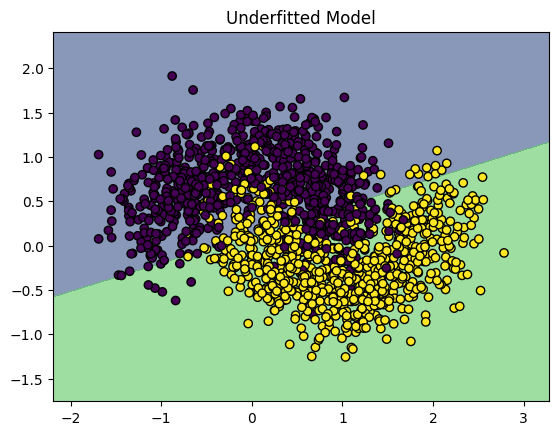

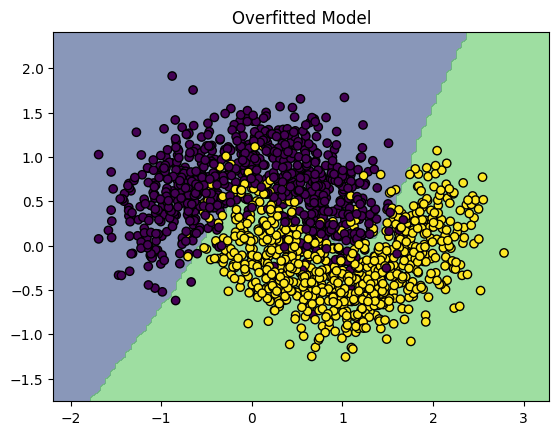

In [13]:
plot_decision_boundary(X_train, y_train, model_underfit, title="Underfitted Model")
plot_decision_boundary(X_train, y_train, model_overfit, title="Overfitted Model")

In [14]:
# Function to evaluate the model on test data
def evaluate_model(model, X_test, y_test, criterion):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        outputs = model(X_test).squeeze()
        loss = criterion(outputs, y_test.squeeze())
        predictions = (outputs > 0.5).float()  # Convert logits to binary labels
        accuracy = (predictions == y_test).float().mean()

    print(f"Test Loss: {loss.item():.4f}, Test Accuracy: {accuracy.item() * 100:.2f}%")
    return loss.item(), accuracy.item()

Test Loss: 8.9813, Test Accuracy: 89.75%
Test Loss: 0.4254, Test Accuracy: 88.75%


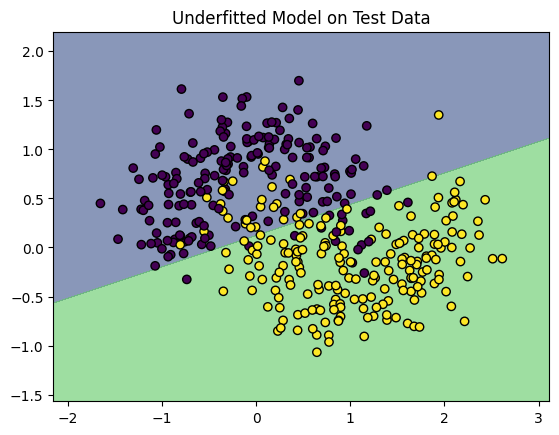

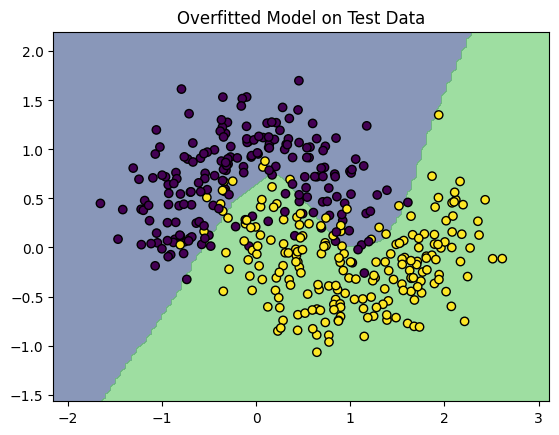

In [15]:
# Evaluate on Test Data
evaluate_model(model_overfit, X_test, y_test, nn.BCELoss())
evaluate_model(model_underfit, X_test, y_test, nn.BCELoss())

# Plot decision boundaries for test data
plot_decision_boundary(X_test, y_test, model_underfit, title="Underfitted Model on Test Data")
plot_decision_boundary(X_test, y_test, model_overfit, title="Overfitted Model on Test Data")

#### experiment 2

Training too simple model with L1 regularization...
epoch 0, loss: 82202.95227050781
epoch 100, loss: 82119.77111816406
epoch 200, loss: 82261.94543457031
epoch 300, loss: 82163.59735107422
epoch 400, loss: 82110.38873291016
epoch 500, loss: 82063.78869628906
epoch 600, loss: 82207.82629394531
epoch 700, loss: 82188.5200805664
epoch 800, loss: 82250.11505126953
epoch 900, loss: 82055.06329345703
Training complicated model with L1 regularization...
epoch 0, loss: 146404.26782226562
epoch 100, loss: 81371.173828125
epoch 200, loss: 81140.35552978516
epoch 300, loss: 81121.79302978516
epoch 400, loss: 81052.03094482422
epoch 500, loss: 81012.47094726562
epoch 600, loss: 81083.42150878906
epoch 700, loss: 81108.50671386719
epoch 800, loss: 81034.30322265625
epoch 900, loss: 80994.45129394531


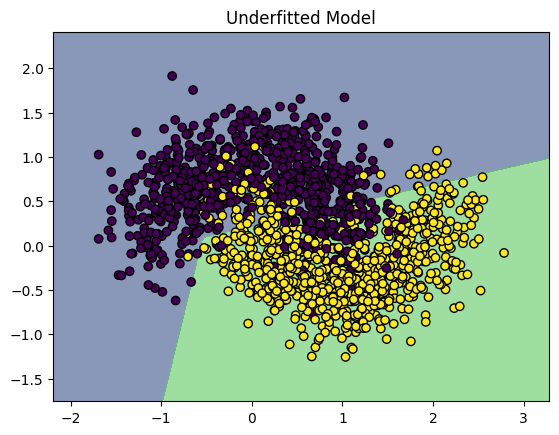

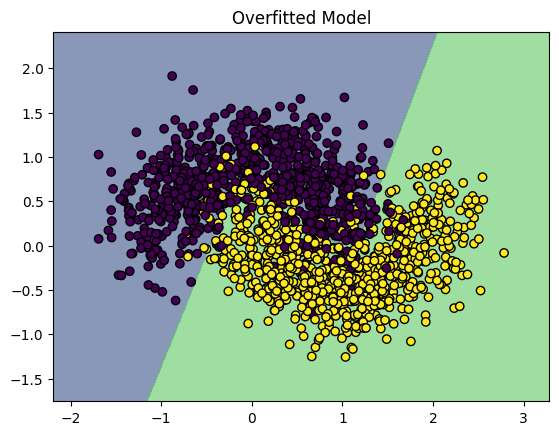

Test Loss: 0.4029, Test Accuracy: 91.00%
Test Loss: 0.3988, Test Accuracy: 89.50%


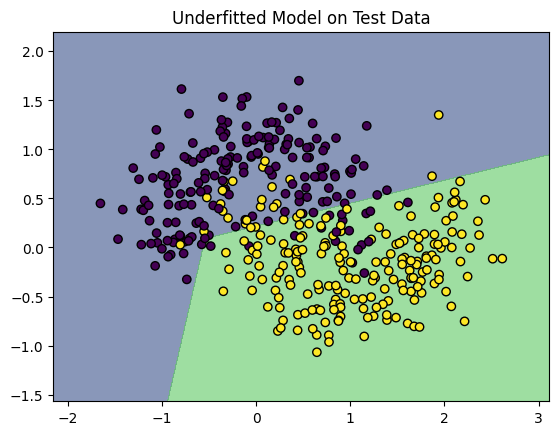

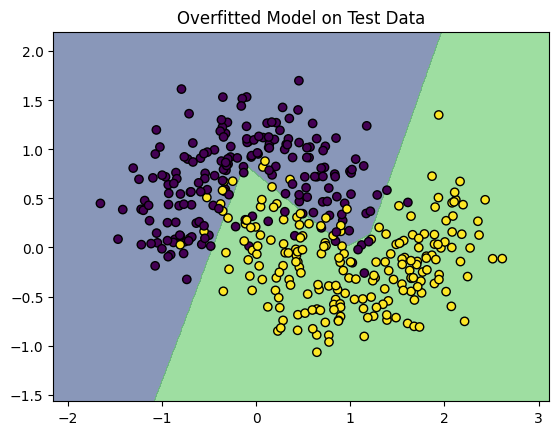

In [16]:
print("Training too simple model with L1 regularization...")
model_underfit = train(simple_model, X_train, y_train, regularization_type="L1")
print("Training complicated model with L1 regularization...")
model_overfit = train(complicated_model, X_train, y_train, regularization_type="L1")

plot_decision_boundary(X_train, y_train, model_underfit, title="Underfitted Model")
plot_decision_boundary(X_train, y_train, model_overfit, title="Overfitted Model")

# Evaluate on Test Data
evaluate_model(model_overfit, X_test, y_test, nn.BCELoss())
evaluate_model(model_underfit, X_test, y_test, nn.BCELoss())

# Plot decision boundaries for test data
plot_decision_boundary(X_test, y_test, model_underfit, title="Underfitted Model on Test Data")
plot_decision_boundary(X_test, y_test, model_overfit, title="Overfitted Model on Test Data")

#### expriment 3

Training too simple model with L2 regularization...
epoch 0, loss: 82523.0386352539
epoch 100, loss: 82295.40417480469
epoch 200, loss: 82219.11254882812
epoch 300, loss: 82267.69274902344
epoch 400, loss: 82251.34423828125
epoch 500, loss: 82199.06231689453
epoch 600, loss: 82248.10729980469
epoch 700, loss: 82199.11114501953
epoch 800, loss: 82286.11224365234
epoch 900, loss: 82306.76391601562
Training complicated model with L2 regularization...
epoch 0, loss: 81158.05590820312
epoch 100, loss: 81149.72979736328
epoch 200, loss: 80997.36572265625
epoch 300, loss: 81009.20373535156
epoch 400, loss: 81011.62927246094
epoch 500, loss: 81043.61120605469
epoch 600, loss: 80936.40301513672
epoch 700, loss: 80927.564453125
epoch 800, loss: 81081.23559570312
epoch 900, loss: 81015.51831054688


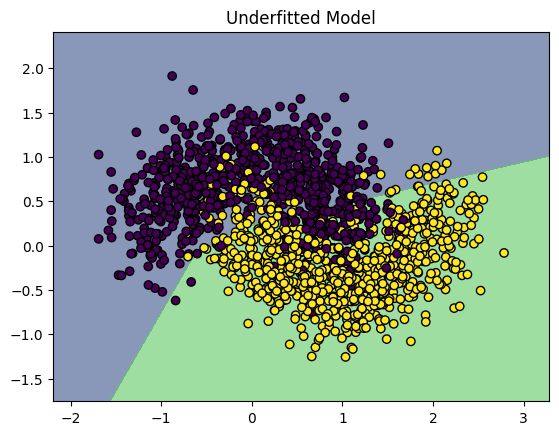

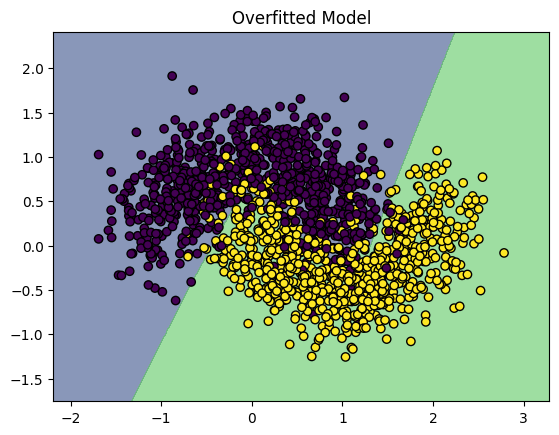

Test Loss: 0.4027, Test Accuracy: 89.25%
Test Loss: 0.3097, Test Accuracy: 89.00%


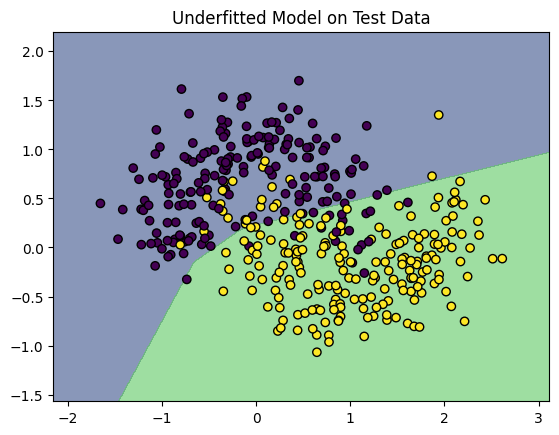

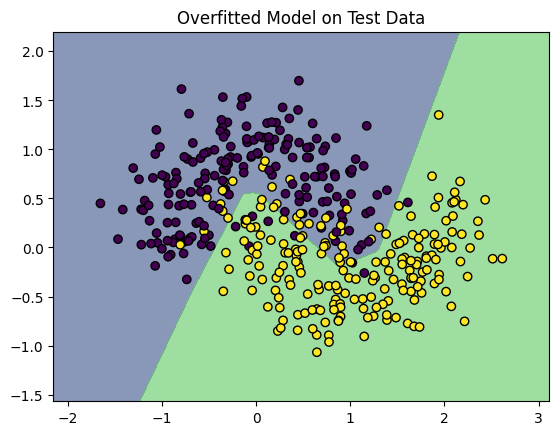

In [17]:
print("Training too simple model with L2 regularization...")
model_underfit = train(simple_model, X_train, y_train, regularization_type="L2")
print("Training complicated model with L2 regularization...")
model_overfit = train(complicated_model, X_train, y_train, regularization_type="L2")

plot_decision_boundary(X_train, y_train, model_underfit, title="Underfitted Model")
plot_decision_boundary(X_train, y_train, model_overfit, title="Overfitted Model")


# Evaluate on Test Data
evaluate_model(model_overfit, X_test, y_test, nn.BCELoss())
evaluate_model(model_underfit, X_test, y_test, nn.BCELoss())

# Plot decision boundaries for test data
plot_decision_boundary(X_test, y_test, model_underfit, title="Underfitted Model on Test Data")
plot_decision_boundary(X_test, y_test, model_overfit, title="Overfitted Model on Test Data")

#### expriment 4

Training too simple model...
epoch 0, loss: 86386.02856445312
epoch 100, loss: 81725.57995605469
epoch 200, loss: 81656.53125
epoch 300, loss: 81688.0679321289
epoch 400, loss: 81704.05633544922
epoch 500, loss: 81736.80615234375
epoch 600, loss: 81667.78356933594
epoch 700, loss: 81666.55377197266
epoch 800, loss: 81672.76782226562
epoch 900, loss: 81738.48718261719
Training complicated model with batch normalization...
epoch 0, loss: 82215.08514404297
epoch 100, loss: 80807.22106933594
epoch 200, loss: 80853.12518310547
epoch 300, loss: 80630.30346679688
epoch 400, loss: 80698.23901367188
epoch 500, loss: 80693.96166992188
epoch 600, loss: 80711.36688232422
epoch 700, loss: 80707.46496582031
epoch 800, loss: 80654.03210449219
epoch 900, loss: 80487.90710449219


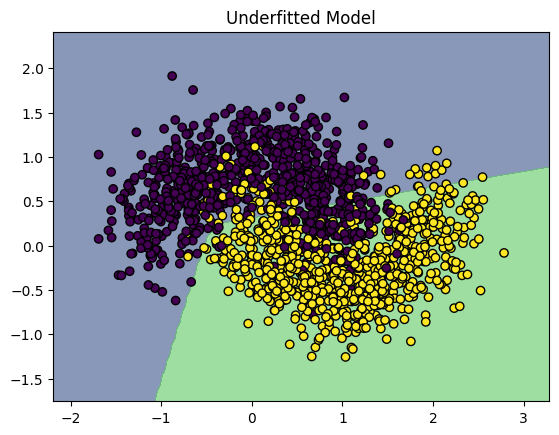

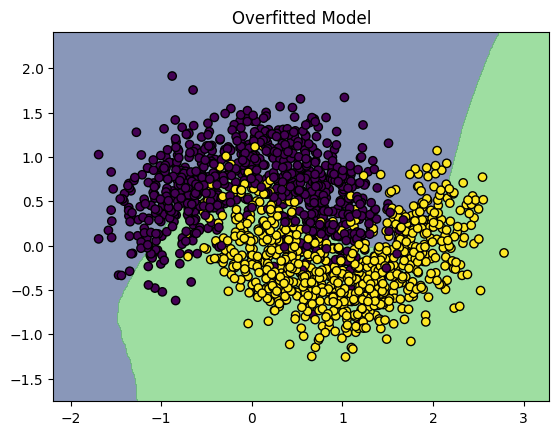

Test Loss: 0.6287, Test Accuracy: 90.00%
Test Loss: 0.5236, Test Accuracy: 88.75%


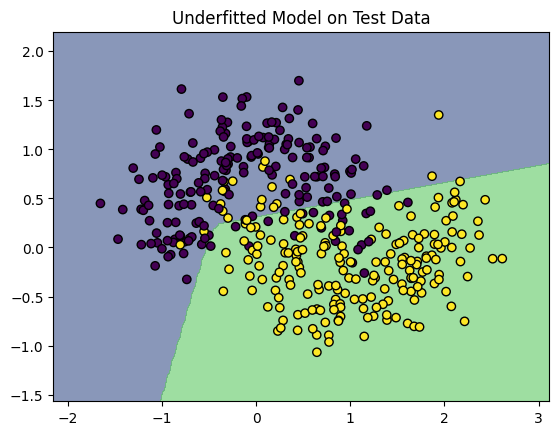

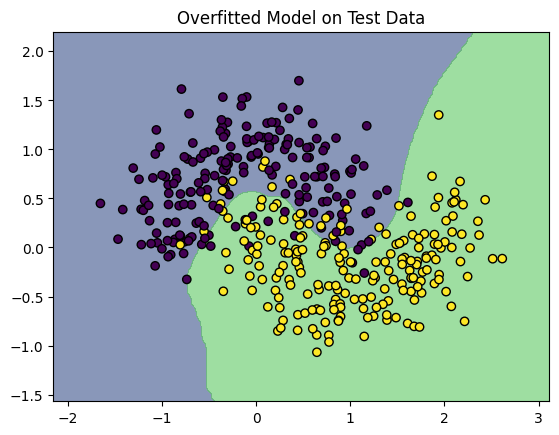

In [22]:

class OverfitNeuralNet2(nn.Module):
    def __init__(self, input_dim):
        super(OverfitNeuralNet2, self).__init__()
       
        self.layer1=nn.Linear(input_dim,128)
        self.bn1=nn.BatchNorm1d(128)
        self.layer2=nn.Linear(128,64)
        self.bn2=nn.BatchNorm1d(64)
        self.layer3=nn.Linear(64,32)
        self.bn3=nn.BatchNorm1d(32)
        self.layer4=nn.Linear(32,16)
        self.layer5=nn.Linear(16,1)

    def forward(self, x):

        x=self.layer1(x)
        x=self.bn1(x)
        x=torch.relu(x)
        x=self.layer2(x)
        x=self.bn2(x)
        x=torch.relu(x)
        x=self.layer3(x)
        x=self.bn3(x)
        x=torch.relu(x)
        x=self.layer4(x)
        x=torch.relu(x)
        x=self.layer5(x)
        x=torch.sigmoid(x)

        return x
    
simple_model=UnderfitNeuralNet(input_dim=2).to(device)
complicated_model=OverfitNeuralNet2(input_dim=2).to(device)


print("Training too simple model...")
model_underfit = train(simple_model, X_train, y_train, regularization_type=None)
print("Training complicated model with batch normalization...")
model_overfit = train(complicated_model, X_train, y_train, regularization_type=None)

plot_decision_boundary(X_train, y_train, model_underfit, title="Underfitted Model")
plot_decision_boundary(X_train, y_train, model_overfit, title="Overfitted Model")


# Evaluate on Test Data
evaluate_model(model_overfit, X_test, y_test, nn.BCELoss())
evaluate_model(model_underfit, X_test, y_test, nn.BCELoss())

# Plot decision boundaries for test data
plot_decision_boundary(X_test, y_test, model_underfit, title="Underfitted Model on Test Data")
plot_decision_boundary(X_test, y_test, model_overfit, title="Overfitted Model on Test Data")

#### expriment 5

Training too simple model...
epoch 0, loss: 87425.3671875
epoch 100, loss: 81580.21618652344
epoch 200, loss: 81589.28985595703
epoch 300, loss: 80888.83288574219
epoch 400, loss: 80454.55224609375
epoch 500, loss: 80464.35748291016
epoch 600, loss: 80371.83544921875
epoch 700, loss: 80293.4560546875
epoch 800, loss: 80312.578125
epoch 900, loss: 80385.69458007812
Training complicated model with dropout after activation function...
epoch 0, loss: 82930.81994628906
epoch 100, loss: 80881.61627197266
epoch 200, loss: 80733.99603271484
epoch 300, loss: 80435.25524902344
epoch 400, loss: 80578.19604492188
epoch 500, loss: 80959.7763671875
epoch 600, loss: 80586.12677001953
epoch 700, loss: 81130.92504882812
epoch 800, loss: 81230.07647705078
epoch 900, loss: 81329.2485961914


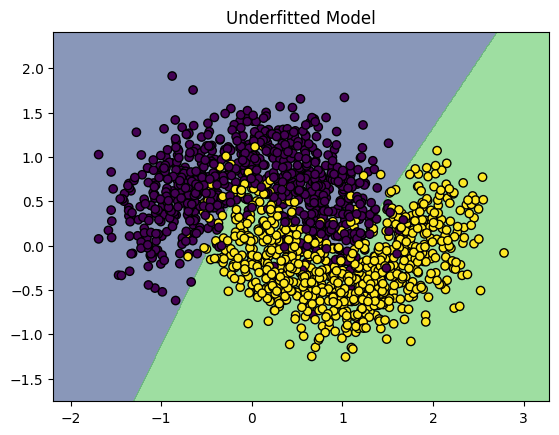

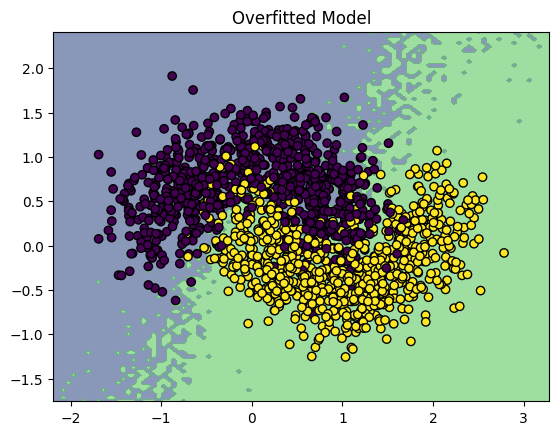

Test Loss: 10.0000, Test Accuracy: 90.00%
Test Loss: 0.5438, Test Accuracy: 91.00%


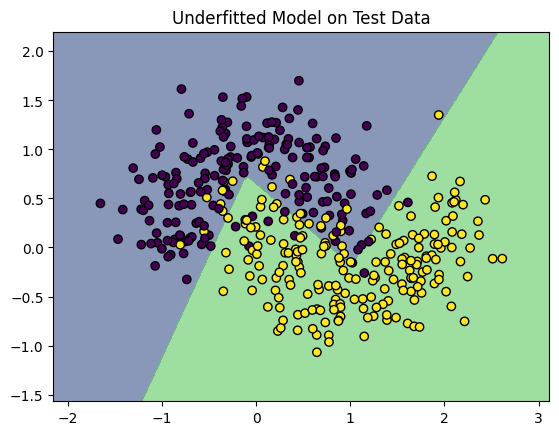

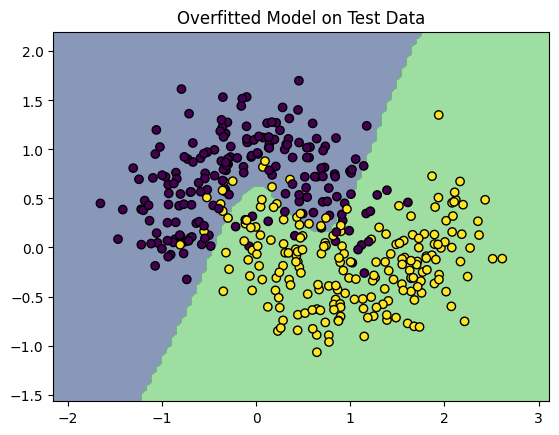

In [21]:
class OverfitNeuralNet3(nn.Module):
    def __init__(self, input_dim):
        super(OverfitNeuralNet3, self).__init__()
       
        self.layer1=nn.Linear(input_dim,128)
        self.dropout1=nn.Dropout(0.2)
        self.layer2=nn.Linear(128,64)
        self.dropout2=nn.Dropout(0.5)
        self.layer3=nn.Linear(64,32)
        self.dropout3=nn.Dropout(0.3)
        self.layer4=nn.Linear(32,16)
        self.layer5=nn.Linear(16,1)

    def forward(self, x):

        x=self.layer1(x)
        x=torch.relu(x)
        x=self.dropout1(x)
        x=self.layer2(x)
        x=torch.relu(x)
        x=self.dropout2(x)
        x=self.layer3(x)
        x=torch.relu(x)
        x=self.dropout3(x)
        x=self.layer4(x)
        x=torch.relu(x)
        x=self.layer5(x)
        x=torch.sigmoid(x)

        return x
    
simple_model=UnderfitNeuralNet(input_dim=2).to(device)
complicated_model=OverfitNeuralNet3(input_dim=2).to(device)


print("Training too simple model...")
model_underfit = train(simple_model, X_train, y_train, regularization_type=None)
print("Training complicated model with dropout after activation function...")
model_overfit = train(complicated_model, X_train, y_train, regularization_type=None)

plot_decision_boundary(X_train, y_train, model_underfit, title="Underfitted Model")
plot_decision_boundary(X_train, y_train, model_overfit, title="Overfitted Model")


# Evaluate on Test Data
evaluate_model(model_overfit, X_test, y_test, nn.BCELoss())
evaluate_model(model_underfit, X_test, y_test, nn.BCELoss())

# Plot decision boundaries for test data
plot_decision_boundary(X_test, y_test, model_underfit, title="Underfitted Model on Test Data")
plot_decision_boundary(X_test, y_test, model_overfit, title="Overfitted Model on Test Data")

Regarding the final accuracy of the model, Lasso regularization and batch normalization and random deletion have increased the accuracy of the model on the test data and improved the generalization of the model. The decision boundaries of the underfitted model without regularizations are a line that tries to separate the data, but in the overfitted model we see a more complex curve that can be a better decision boundary.